<a href="https://colab.research.google.com/github/flahbocchino/cardioia-fase3-iot-monitoramento_flaviabocchino/blob/main/cardioia_iralem2_series_temporais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# CardioIA - Fase 3 | Ir Além 2: IA em Séries Temporais
# Aluna: Flávia Bocchino | RM: 564213
# Comparação: Regressão Logística vs Rede Neuromórfica (LIF)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

In [9]:
# Geração de dados simulados de sinais vitais (série temporal)
np.random.seed(42)
n = 500

tempo = np.arange(n)
bpm_normal = 70 + 10 * np.sin(2 * np.pi * tempo / 50) + np.random.normal(0, 3, n)
bpm_risco  = 110 + 15 * np.sin(2 * np.pi * tempo / 30) + np.random.normal(0, 5, n)

bpm = np.concatenate([bpm_normal, bpm_risco])
rotulo = np.concatenate([np.zeros(n), np.ones(n)])  # 0 = normal, 1 = risco

# Features: valor atual + média móvel de 5 pontos
df = pd.DataFrame({'bpm': bpm, 'rotulo': rotulo})
df['media_movel'] = df['bpm'].rolling(5).mean().fillna(df['bpm'])
df['variacao'] = df['bpm'].diff().fillna(0)

print("Dataset criado:", df.shape)
print(df.head())

Dataset criado: (1000, 4)
         bpm  rotulo  media_movel  variacao
0  71.490142     0.0    71.490142  0.000000
1  70.838539     0.0    70.838539 -0.651603
2  74.429964     0.0    74.429964  3.591425
3  78.250335     0.0    78.250335  3.820371
4  74.115077     0.0    73.824812 -4.135258


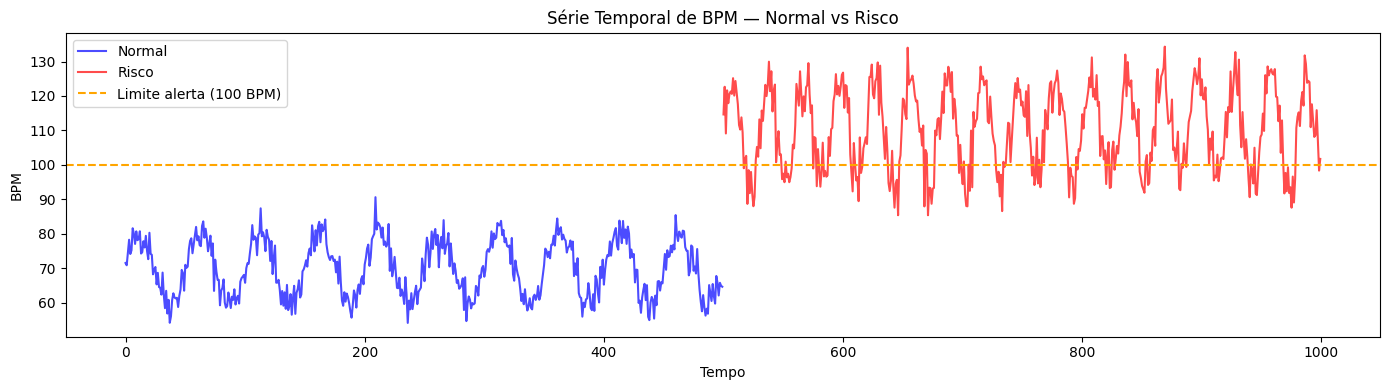

In [10]:
# Visualização dos sinais
plt.figure(figsize=(14, 4))
plt.plot(tempo, bpm_normal, label='Normal', color='blue', alpha=0.7)
plt.plot(tempo + n, bpm_risco, label='Risco', color='red', alpha=0.7)
plt.axhline(y=100, color='orange', linestyle='--', label='Limite alerta (100 BPM)')
plt.title('Série Temporal de BPM — Normal vs Risco')
plt.xlabel('Tempo')
plt.ylabel('BPM')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Preparação dos dados
X = df[['bpm', 'media_movel', 'variacao']].values
y = df['rotulo'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

Treino: (800, 3) | Teste: (200, 3)


In [12]:
# MODELO 1: Regressão Logística (classificador tradicional)
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("=== Regressão Logística ===")
print(f"Acurácia: {acc_lr:.4f}")
print(classification_report(y_test, y_pred_lr, target_names=['Normal', 'Risco']))

=== Regressão Logística ===
Acurácia: 1.0000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        96
       Risco       1.00      1.00      1.00       104

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [13]:
# MODELO 2: Rede Neuromórfica simples (modelo LIF - Leaky Integrate-and-Fire)
# Implementação manual do neurônio LIF

def lif_neuron(input_signal, threshold=1.0, tau=10.0, dt=0.1):
    """Simula um neurônio LIF e retorna sequência de spikes"""
    V = 0.0
    spikes = []
    for s in input_signal:
        V += dt * (-V / tau + s)
        if V >= threshold:
            spikes.append(1)
            V = 0.0
        else:
            spikes.append(0)
    return np.array(spikes)

def classificar_lif(X_data, threshold=1.0):
    """Classifica cada amostra com base na taxa de spikes do LIF"""
    predicoes = []
    for amostra in X_data:
        signal = np.abs(amostra)
        spikes = lif_neuron(signal, threshold=threshold)
        taxa_spike = spikes.mean()
        predicoes.append(1 if taxa_spike > 0.3 else 0)
    return np.array(predicoes)

y_pred_lif = classificar_lif(X_test)
acc_lif = accuracy_score(y_test, y_pred_lif)

print("=== Rede Neuromórfica (LIF) ===")
print(f"Acurácia: {acc_lif:.4f}")
print(classification_report(y_test, y_pred_lif, target_names=['Normal', 'Risco']))

=== Rede Neuromórfica (LIF) ===
Acurácia: 0.4800
              precision    recall  f1-score   support

      Normal       0.48      1.00      0.65        96
       Risco       0.00      0.00      0.00       104

    accuracy                           0.48       200
   macro avg       0.24      0.50      0.32       200
weighted avg       0.23      0.48      0.31       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


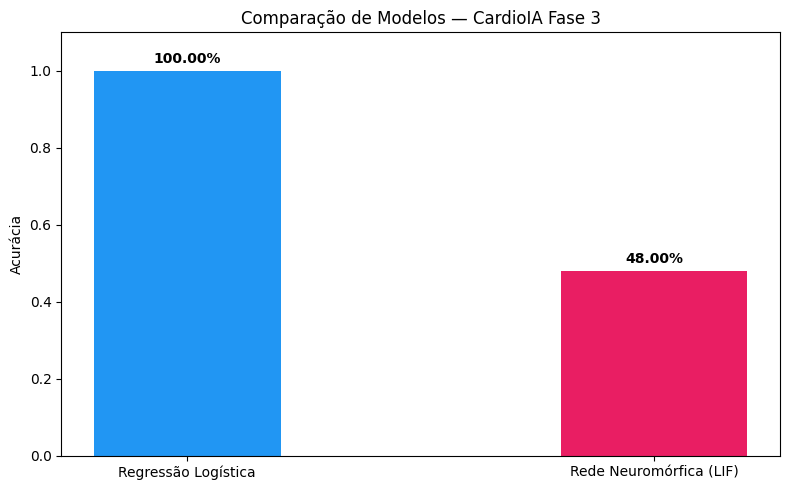


Regressão Logística: 100.00%
Rede Neuromórfica LIF: 48.00%


In [14]:
# Comparação visual dos modelos
modelos = ['Regressão Logística', 'Rede Neuromórfica (LIF)']
acuracias = [acc_lr, acc_lif]

plt.figure(figsize=(8, 5))
bars = plt.bar(modelos, acuracias, color=['#2196F3', '#E91E63'], width=0.4)
plt.ylim(0, 1.1)
plt.ylabel('Acurácia')
plt.title('Comparação de Modelos — CardioIA Fase 3')
for bar, acc in zip(bars, acuracias):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nRegressão Logística: {acc_lr:.2%}")
print(f"Rede Neuromórfica LIF: {acc_lif:.2%}")